# 06 — Comparison 2566 vs 2569
**Ubon Ratchathani Constituency 10** | Data Science Project 2025/2

Comparing election results between 2023 (2566) and 2026 (2569):
1. Overall vote share shift per party
2. Turnout comparison (2566 has registered voters data)
3. Swing analysis per amphoe — which areas changed the most
4. Party-list shift 2566 vs 2569

## 0 · Imports & Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RAW  = Path('../data-final')
OUT  = Path('../data-processed/6')
FIG  = Path('../figures')
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# 2569 processed data
const_by_amphoe = pd.read_csv('../data-processed/1/constituency_by_amphoe.csv')
const_overall   = pd.read_csv('../data-processed/2/const_overall.csv')
party_overall   = pd.read_csv('../data-processed/3/partylist_overall.csv')
cand_map        = pd.read_csv('../data-processed/1/candidate_mapping.csv')

# 2566 raw data
scores_66 = pd.read_csv(RAW / 'election_scores_2566.csv')
loc_66    = pd.read_csv(RAW / 'election_locations_66.csv')

print('Loaded OK')

Loaded OK


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Use a font that supports Thai — try system fonts first
thai_fonts = ['Tahoma', 'Arial Unicode MS', 'Noto Sans Thai', 'TH Sarabun New', 'FreeSans']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in thai_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'Using font: {chosen}')
else:
    print('No Thai font found — labels may be garbled')
    print('Available fonts sample:', available[:10])

Using font: Tahoma


## 1 · Filter 2566 Data for Constituency 10

Constituency 10 (2566 boundary):
- อำเภอน้ำยืน, น้ำขุ่น, ทุ่งศรีอุดม — all subdistricts
- อำเภอเดชอุดม — เฉพาะตำบลทุ่งเทิง
- อำเภอสำโรง — ยกเว้นตำบลบอน, โคกก่อง, สำโรง

In [4]:
ubon = scores_66[scores_66['province'].str.contains('อุบล', na=False)].copy()

# Full amphoes
full_amphoes = ['น้ำยืน', 'น้ำขุ่น', 'ทุ่งศรีอุดม']

# Partial: เดชอุดม เฉพาะทุ่งเทิง
detchudom = ubon[
    (ubon['district'] == 'เดชอุดม') &
    (ubon['subdistrict'] == 'ทุ่งเทิง')
]

# Partial: สำโรง ยกเว้น บอน, โคกก่อง, สำโรง
samrong_exclude = ['บอน', 'โคกก่อง', 'สำโรง']
samrong = ubon[
    (ubon['district'] == 'สำโรง') &
    (~ubon['subdistrict'].isin(samrong_exclude))
]

full = ubon[ubon['district'].isin(full_amphoes)]
df66 = pd.concat([full, detchudom, samrong], ignore_index=True)

print(f'Total stations 2566: {len(df66)}')
print('\nStations per district:')
print(df66['district'].value_counts())

Total stations 2566: 313

Stations per district:
district
น้ำยืน         117
สำโรง           73
น้ำขุ่น         56
ทุ่งศรีอุดม     52
เดชอุดม         15
Name: count, dtype: int64


## 2 · 2566 Constituency — Overall Vote Share

In 2566, เพื่อไทรวมพลัง did not exist yet.
The winner was สมศักดิ์ บุญประชม running under เพื่อไทรวมพลัง.
Map 2566 parties to 2569 equivalents where possible.

In [5]:
# 2566 constituency columns in this data
const_cols_66 = [c for c in df66.columns if c.startswith('เขต_') and
                 c not in ['เขต_ผู้มีสิทธิ์', 'เขต_ผู้มาใช้สิทธิ์', 'เขต_บัตรเสีย', 'เขต_ไม่เลือกผู้ใด']]

const_66 = df66[const_cols_66].sum().reset_index()
const_66.columns = ['party_col', 'votes_2566']
const_66['party_name'] = const_66['party_col'].str.replace('เขต_', '', regex=False)
const_66 = const_66[const_66['votes_2566'] > 0].sort_values('votes_2566', ascending=False)
const_66['vote_share_%'] = (const_66['votes_2566'] / const_66['votes_2566'].sum() * 100).round(2)

print('=== 2566 Constituency Vote Share ===')
print(const_66[['party_name', 'votes_2566', 'vote_share_%']].to_string(index=False))

=== 2566 Constituency Vote Share ===
     party_name  votes_2566  vote_share_%
 เพื่อไทรวมพลัง     57457.0         66.66
       เพื่อไทย     16945.0         19.66
        ก้าวไกล      7309.0          8.48
      ภูมิใจไทย      1071.0          1.24
รวมไทยสร้างชาติ       792.0          0.92
   พลังประชารัฐ       764.0          0.89
   ทางเลือกใหม่       672.0          0.78
   ประชาธิปัตย์       247.0          0.29
      เพื่อชาติ       195.0          0.23
     เสรีรวมไทย       193.0          0.22
   ไทยศรีวิไลย์       178.0          0.21
     แนวทางใหม่       149.0          0.17
       ไทยภักดี       123.0          0.14
        คลองไทย        68.0          0.08
   พลังปวงชนไทย        27.0          0.03


In [7]:
# 2569 constituency for comparison
const_69 = const_overall[['party_name', 'score', 'vote_share_%']].copy()
const_69.columns = ['party_name', 'votes_2569', 'vote_share_2569_%']

# Map 2566 → 2569 party names for comparison
party_map_66_to_69 = {
    'เพื่อไทรวมพลัง': 'เพื่อไทรวมพลัง',
    'เพื่อไทย':       'เพื่อไทย',
    'ภูมิใจไทย':      'ภูมิใจไทย',
    'พลังประชารัฐ':   'พลังประชารัฐ',
    'ก้าวไกล':        'ประชาชน',   # ก้าวไกล → ยุบ → ประชาชน
    'ประชาธิปัตย์':   'ประชาธิปัตย์',
}

const_66['party_69'] = const_66['party_name'].map(party_map_66_to_69)

compare_const = (
    const_66[const_66['party_69'].notna()]
    [['party_69', 'votes_2566', 'vote_share_%']]
    .rename(columns={'party_69': 'party_name', 'vote_share_%': 'share_2566_%'})
    .merge(const_69, on='party_name', how='outer')
    .fillna(0)
)
compare_const['swing_pp'] = (
    compare_const['vote_share_2569_%'] - compare_const['share_2566_%']
).round(2)

print('=== Constituency Swing 2566 → 2569 ===')
print(compare_const[['party_name', 'share_2566_%', 'vote_share_2569_%', 'swing_pp']]
      .sort_values('swing_pp', ascending=False).to_string(index=False))

=== Constituency Swing 2566 → 2569 ===
    party_name  share_2566_%  vote_share_2569_%  swing_pp
เพื่อไทรวมพลัง         66.66              80.41     13.75
     ภูมิใจไทย          1.24               4.13      2.89
  พลังประชารัฐ          0.89               1.18      0.29
  ประชาธิปัตย์          0.29               0.34      0.05
       ประชาชน          8.48               6.44     -2.04
      เพื่อไทย         19.66               7.50    -12.16


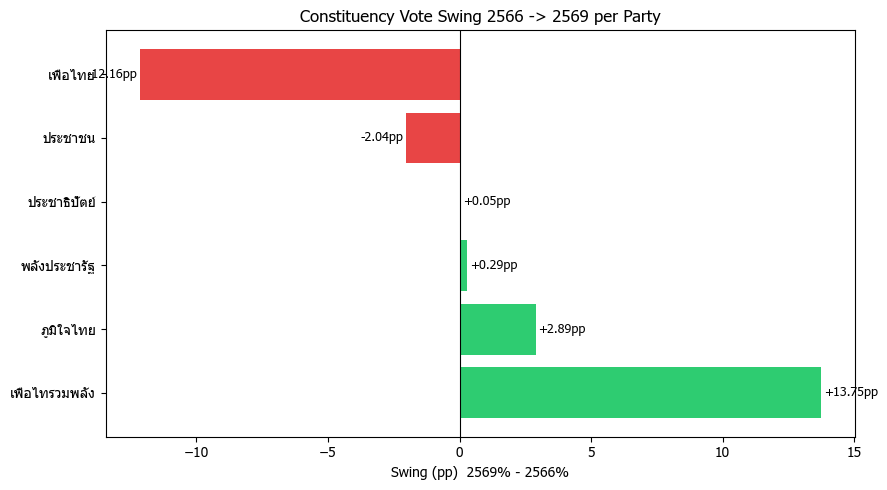

In [11]:
comp = compare_const.sort_values('swing_pp')
colors = ['#e84545' if v < 0 else '#2ecc71' for v in comp['swing_pp']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(comp['party_name'], comp['swing_pp'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Swing (pp)  2569% - 2566%')
ax.set_title('Constituency Vote Swing 2566 -> 2569 per Party')
for bar, val in zip(bars, comp['swing_pp']):
    offset = 0.1 if val >= 0 else -0.1
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}pp', va='center', ha=ha, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'swing_2566_2569_constituency.png', dpi=150)
plt.show()

## 3 · Swing per Amphoe

Which amphoe shifted the most between 2566 and 2569?

In [16]:
# 2566 votes per party per district
amphoe_map = {
    'น้ำยืน':      'อำเภอน้ำยืน',
    'น้ำขุ่น':     'อำเภอน้ำขุ่น',
    'ทุ่งศรีอุดม': 'อำเภอทุ่งศรีอุดม',
    'เดชอุดม':    'อำเภอเดชอุดม (เฉพาะตำบลทุ่งเทิง)',
    'สำโรง':      'อำเภอสำโรง',
}

# Winner party per district 2566
winner_66_rows = []
for dist66, amp69 in amphoe_map.items():
    sub = df66[df66['district'] == dist66]
    if len(sub) == 0:
        continue
    party_votes = {
        col.replace('เขต_', ''): sub[col].sum()
        for col in const_cols_66 if col in sub.columns
    }
    best_party = max(party_votes, key=party_votes.get)
    best_votes = party_votes[best_party]
    total      = sum(party_votes.values())
    winner_66_rows.append({
        'amphoe':       amp69,
        'winner_2566':  best_party,
        'votes_2566':   best_votes,
        'share_2566_%': round(best_votes / total * 100, 2) if total > 0 else 0,
    })

winner_66 = pd.DataFrame(winner_66_rows)

# Winner per amphoe 2569
winner_69 = (
    const_by_amphoe
    .sort_values('score', ascending=False)
    .groupby('amphoe').first().reset_index()
    [['amphoe', 'party_name', 'score']]
    .rename(columns={'party_name': 'winner_2569', 'score': 'votes_2569'})
)
amphoe_total_69 = const_by_amphoe.groupby('amphoe')['score'].sum().reset_index().rename(columns={'score': 'total_2569'})
winner_69 = winner_69.merge(amphoe_total_69, on='amphoe')
winner_69['share_2569_%'] = (winner_69['votes_2569'] / winner_69['total_2569'] * 100).round(2)

swing_amphoe = winner_66.merge(winner_69, on='amphoe', how='inner')
swing_amphoe['same_winner'] = swing_amphoe['winner_2566'].apply(
    lambda w: party_map_66_to_69.get(w, w)
) == swing_amphoe['winner_2569']

print('=== Amphoe-level Swing ===')
print(swing_amphoe[['amphoe', 'winner_2566', 'share_2566_%',
                     'winner_2569', 'share_2569_%', 'same_winner']].to_string(index=False))

=== Amphoe-level Swing ===
          amphoe    winner_2566  share_2566_%    winner_2569  share_2569_%  same_winner
     อำเภอน้ำยืน เพื่อไทรวมพลัง         76.30 เพื่อไทรวมพลัง         90.94         True
    อำเภอน้ำขุ่น เพื่อไทรวมพลัง         71.61 เพื่อไทรวมพลัง         88.01         True
อำเภอทุ่งศรีอุดม เพื่อไทรวมพลัง         65.18 เพื่อไทรวมพลัง         79.94         True
      อำเภอสำโรง เพื่อไทรวมพลัง         52.30 เพื่อไทรวมพลัง         64.72         True


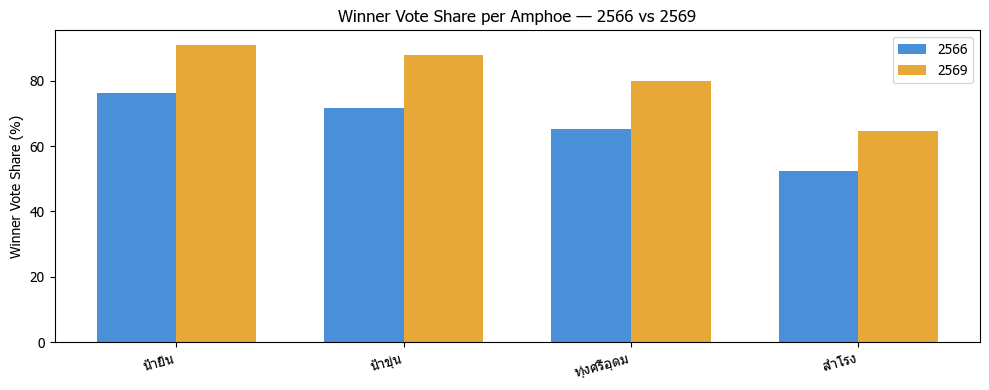

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(swing_amphoe))
w = 0.35

ax.bar(x - w/2, swing_amphoe['share_2566_%'], width=w, color='#4a90d9', label='2566')
ax.bar(x + w/2, swing_amphoe['share_2569_%'], width=w, color='#e8a838', label='2569')

ax.set_xticks(x)
ax.set_xticklabels(
    [a.replace('อำเภอ', '') for a in swing_amphoe['amphoe']],
    rotation=15, ha='right'
)
ax.set_ylabel('Winner Vote Share (%)')
ax.set_title('Winner Vote Share per Amphoe — 2566 vs 2569')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'swing_amphoe.png', dpi=150)
plt.show()

## 4 · Party-list Shift 2566 → 2569

Compare party-list vote share for key parties across both elections.
Note: ก้าวไกล (2566) → ประชาชน (2569) after dissolution.

In [18]:
# 2566 party-list
bch_cols_66 = [c for c in df66.columns if c.startswith('บช_') and
               c not in ['บช_ผู้มีสิทธิ์', 'บช_ผู้มาใช้สิทธิ์', 'บช_บัตรเสีย', 'บช_ไม่เลือกผู้ใด']]

party_66 = df66[bch_cols_66].sum().reset_index()
party_66.columns = ['party_col', 'votes_2566']
party_66['party_name'] = party_66['party_col'].str.replace('บช_', '', regex=False)
party_66 = party_66[party_66['votes_2566'] > 0].sort_values('votes_2566', ascending=False)
party_66['share_2566_%'] = (party_66['votes_2566'] / party_66['votes_2566'].sum() * 100).round(2)

# Map to 2569 names
bch_map_66_to_69 = {
    'เพื่อไทย':    'เพื่อไทย',
    'ก้าวไกล':     'ประชาชน',
    'ภูมิใจไทย':   'ภูมิใจไทย',
    'พลังประชารัฐ':'พลังประชารัฐ',
    'ประชาธิปัตย์':'ประชาธิปัตย์',
    'รวมไทยสร้างชาติ': 'รวมไทยสร้างชาติ',
    'เสรีรวมไทย':  'เสรีรวมไทย',
    'ไทยสร้างไทย': 'ไทยสร้างไทย',
}

party_66['party_69'] = party_66['party_name'].map(bch_map_66_to_69)

# 2569 party-list
party_69 = party_overall[['party_name', 'party_votes', 'party_%']].rename(
    columns={'party_votes': 'votes_2569', 'party_%': 'share_2569_%'}
)

compare_party = (
    party_66[party_66['party_69'].notna()]
    [['party_69', 'votes_2566', 'share_2566_%']]
    .rename(columns={'party_69': 'party_name'})
    .merge(party_69, on='party_name', how='outer')
    .fillna(0)
)
compare_party['swing_pp'] = (compare_party['share_2569_%'] - compare_party['share_2566_%']).round(2)
compare_party = compare_party.sort_values('swing_pp')

print('=== Party-list Swing 2566 → 2569 ===')
print(compare_party[['party_name', 'share_2566_%', 'share_2569_%', 'swing_pp']].to_string(index=False))

=== Party-list Swing 2566 → 2569 ===
                 party_name  share_2566_%  share_2569_%  swing_pp
                   เพื่อไทย         56.75          6.81    -49.94
                    ประชาชน         32.53          5.20    -27.33
            รวมไทยสร้างชาติ          5.82          0.73     -5.09
               พลังประชารัฐ          0.81          0.54     -0.27
                  ภูมิใจไทย          1.47          1.30     -0.17
               ประชาธิปัตย์          0.83          0.71     -0.12
                 เสรีรวมไทย          0.71          0.85      0.14
                 วิชชันใหม่          0.00          0.30      0.30
              สร้างอนาคตไทย          0.00          0.33      0.33
              พลังสังคมใหม่          0.00          0.33      0.33
                ไทยก้าวใหม่          0.00          0.34      0.34
                  ประชาชาติ          0.00          0.38      0.38
            แรงงานสร้างชาติ          0.00          0.38      0.38
             เพื่อชีวิตใหม่          0.

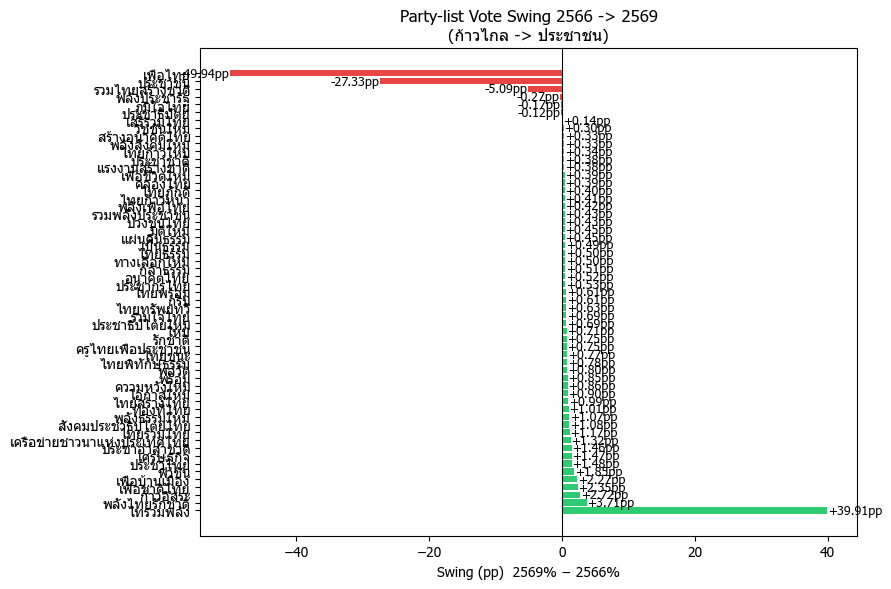

In [20]:
colors = ['#e84545' if v < 0 else '#2ecc71' for v in compare_party['swing_pp']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(compare_party['party_name'], compare_party['swing_pp'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Swing (pp)  2569% − 2566%')
ax.set_title('Party-list Vote Swing 2566 -> 2569\n(ก้าวไกล -> ประชาชน)')
for bar, val in zip(bars, compare_party['swing_pp']):
    offset = 0.1 if val >= 0 else -0.1
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}pp', va='center', ha=ha, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'swing_2566_2569_partylist.png', dpi=150)
plt.show()

## 5 · Export

In [21]:
compare_const.to_csv(OUT / 'swing_constituency_2566_2569.csv', index=False, encoding='utf-8-sig')
compare_party.to_csv(OUT / 'swing_partylist_2566_2569.csv',    index=False, encoding='utf-8-sig')
swing_amphoe.to_csv(OUT / 'swing_amphoe_2566_2569.csv',        index=False, encoding='utf-8-sig')

print('Exported OK')

Exported OK


## Summary

| File | Description |
|------|-------------|
| `swing_constituency_2566_2569.csv` | Constituency swing per party |
| `swing_partylist_2566_2569.csv` | Party-list swing per party |
| `swing_amphoe_2566_2569.csv` | Winner + share shift per amphoe |

**Next:** `07_border_events.ipynb` — Thai-Cambodia border events overlay